# Reusable EDA & Data Cleaning Template

This notebook is a cookie-cutter template for any new dataset.
Follow cells top-to-bottom and validate output at each step.

In [3]:
# Imports & configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('ggplot')

In [4]:
# Load dataset (update file path)
df = pd.read_csv(r'C:\Users\zaids\Downloads\raw_transactions_dummy.csv')
df.head()

,transaction_id,customer_id,transaction_date,amount_usd,payment_type,currency
0,10052,535,2024-06-03,103.73,wallet,SGD
1,10093,533,2024-03-03,127.30,wallet,USD
2,10015,505,2024-06-26,219.51,Bank Transfer,GBP
3,10072,542,2024-06-27,6.69,wallet,USD
4,10061,539,2024-04-27,781.84,Bank Transfer,USD


In [3]:
# Dataset shape & columns
df.shape
df.columns.tolist()

['transaction_id',
 'customer_id',
 'transaction_date',
 'amount_usd',
 'payment_type',
 'currency']

In [4]:
# Schema & data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    130 non-null    int64  
 1   customer_id       130 non-null    int64  
 2   transaction_date  130 non-null    object 
 3   amount_usd        130 non-null    float64
 4   payment_type      123 non-null    object 
 5   currency          125 non-null    object 
dtypes: float64(1), int64(2), object(3)
memory usage: 6.2+ KB


In [7]:
# Summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_id,130.0,10050.646154,29.189268,10001.0,10024.000,10053.00,10075.0000,10100.00
customer_id,130.0,526.192308,14.772222,501.0,513.000,528.00,539.0000,549.00
amount_usd,130.0,131.019308,149.834436,-1.0,30.865,77.91,174.4075,781.84


In [ ]:
# Categorical columns overview
categorical_cols = df.select_dtypes(include='object').columns.tolist()

for col in categorical_cols:
    print(f'\nColumn: {col}')
    print(df[col].value_counts(dropna=False).head(10)) # what does dropna = False do? 


Column: transaction_date
transaction_date
2024-05-22    6
2024-05-21    4
2024-06-30    4
2024-05-02    4
2024-06-04    4
2024-04-03    3
2024-02-12    3
2024-04-20    3
2024-03-03    2
2024-04-01    2
Name: count, dtype: int64

Column: payment_type
payment_type
Card             45
Bank Transfer    36
wallet           21
card             21
NaN               7
Name: count, dtype: int64

Column: currency
currency
USD    59
INR    29
GBP    20
SGD    17
NaN     5
Name: count, dtype: int64


In [8]:
df.columns.tolist()

['transaction_id',
 'customer_id',
 'transaction_date',
 'amount_usd',
 'payment_type',
 'currency']

In [6]:
for col in df.columns:
    print(f'\nColumn: {col}')
    print(df[col].value_counts(dropna=False).head(10))
    print('---' * 10)


Column: transaction_id
transaction_id
10062    6
10060    5
10053    5
10015    4
10089    4
10002    4
10088    4
10004    3
10008    3
10071    3
Name: count, dtype: int64
------------------------------

Column: customer_id
customer_id
539    7
549    7
532    7
544    6
528    6
502    6
537    6
533    6
509    4
535    4
Name: count, dtype: int64
------------------------------

Column: transaction_date
transaction_date
2024-05-22    6
2024-05-21    4
2024-06-30    4
2024-05-02    4
2024-06-04    4
2024-04-03    3
2024-02-12    3
2024-04-20    3
2024-03-03    2
2024-04-01    2
Name: count, dtype: int64
------------------------------

Column: amount_usd
amount_usd
-1.00      6
 54.73     2
 66.63     2
 54.20     2
 41.12     2
 2.60      2
 7.39      2
 216.19    2
 263.92    2
 79.49     2
Name: count, dtype: int64
------------------------------

Column: payment_type
payment_type
Card             45
Bank Transfer    36
wallet           21
card             21
NaN               7
N

In [35]:
# Missing values analysis
df.isnull().mean().mul(100).round(2).sort_values(ascending=False)

payment_type        5.38
currency            3.85
customer_id         0.00
transaction_id      0.00
amount_usd          0.00
transaction_date    0.00
dtype: float64

In [36]:
# Duplicate rows check
df.duplicated().sum()
df[df.duplicated(keep=False)]   # isme agar sab columns ki value foe a particular row same hai to wo duplicate consider hoga

,transaction_id,customer_id,transaction_date,amount_usd,payment_type,currency
15,10053,524,2024-06-30,54.73,Card,USD
26,10058,547,2024-05-22,66.63,Card,USD
57,10053,507,2024-05-21,54.20,card,SGD
60,10092,502,2024-05-22,263.92,Card,GBP
66,10035,544,2024-04-20,79.49,Card,USD
84,10062,509,2024-07-02,41.12,card,INR
86,10014,533,2024-06-04,-1.00,Bank Transfer,SGD
103,10041,549,2024-04-23,2.60,Bank Transfer,GBP
104,10029,517,2024-01-17,216.19,Bank Transfer,USD
109,10071,523,2024-06-25,7.39,card,INR


In [37]:
# Business key duplicate check (update keys)
# “Show me every row where transaction_id appears more than once.”

business_key = ['transaction_id']  # Replace with actual business key columns  # isme on the basis of a particular column it look for a duplicate 
df[df.duplicated(subset=business_key, keep=False)].sort_values(business_key)

,transaction_id,customer_id,transaction_date,amount_usd,payment_type,currency
16,10002,537,2024-03-05,31.78,Card,USD
20,10002,522,2024-06-30,75.30,Card,USD
72,10002,525,2024-03-19,6.29,card,INR
58,10002,522,2024-02-12,115.53,card,INR
13,10003,548,2024-04-01,589.31,Card,USD
44,10003,532,2024-05-18,7.82,Card,USD
51,10004,515,2024-02-12,25.27,Card,USD
71,10004,528,2024-04-08,188.08,Bank Transfer,USD
75,10004,501,2024-05-27,204.41,Bank Transfer,USD
64,10008,528,2024-06-04,276.80,wallet,USD


In [38]:
# Drop exact duplicates
df = df.drop_duplicates(subset="transaction_id", keep='first')  # isme on the basis of a particular column it look for a duplicate and first occurrence ko rakhta hai
df.duplicated().sum()

np.int64(0)

In [39]:
df[df.duplicated(subset="transaction_id", keep=False)].sort_values("transaction_id") 
# now there should be no duplicate transaction_id, if there are then we need to investigate further

,transaction_id,customer_id,transaction_date,amount_usd,payment_type,currency


In [40]:
# Numeric validation
numeric_cols = df.select_dtypes(include=np.number).columns.tolist() # isme numeric type ke columns ko select kiya hai
for col in numeric_cols:
    print(f'{col}: {(df[col] < 0).sum()} negative values')

transaction_id: 0 negative values
customer_id: 0 negative values
amount_usd: 4 negative values


In [41]:
# Method 1: Drop rows with invalid negative amounts

# Drop rows with invalid negative amounts
df = df[df["amount_usd"] >= 0]

# Validate fix
(df["amount_usd"] < 0).sum()


np.int64(0)

In [42]:
# now validate if there are any negative values left in amount_usd, if there are then we need to investigate further
for col in numeric_cols:
    print(f'{col}: {(df[col] < 0).sum()} negative values')

transaction_id: 0 negative values
customer_id: 0 negative values
amount_usd: 0 negative values


In [ ]:
# Method 2
# Replace negative values with NaN
df.loc[df["amount_usd"] < 0, "amount_usd"] = np.nan


df["amount_usd"] = np.where(df["amount_usd"] < 0, np.nan, df["amount_usd"]) # this is another way to replace negative values with NaN in the 'amount_usd' column


# Impute using median (or other rule)
df["amount_usd"] = df["amount_usd"].fillna(df["amount_usd"].median())


In [44]:
df.head()

,transaction_id,customer_id,transaction_date,amount_usd,payment_type,currency
0,10052,535,2024-06-03,103.73,wallet,SGD
1,10093,533,2024-03-03,127.30,wallet,USD
2,10015,505,2024-06-26,219.51,Bank Transfer,GBP
3,10072,542,2024-06-27,6.69,wallet,USD
4,10061,539,2024-04-27,781.84,Bank Transfer,USD


In [45]:
# Date parsing (update column)
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')
df['transaction_date'].isnull().sum()

np.int64(0)

In [46]:
df[df["amount_usd"] < 0]


,transaction_id,customer_id,transaction_date,amount_usd,payment_type,currency


In [47]:
# Clean categorical text
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

In [48]:
# Handle missing values
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())
for col in categorical_cols:
    df[col] = df[col].fillna('unknown')

In [49]:
# Outlier detection (IQR)
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f'{col}: {outliers.shape[0]} outliers')

transaction_id: 0 outliers
customer_id: 0 outliers
amount_usd: 6 outliers


In [50]:
print(outliers)

    transaction_id  customer_id transaction_date  amount_usd   payment_type  \
4            10061          539       2024-04-27      781.84  bank transfer   
13           10003          548       2024-04-01      589.31           card   
22           10060          535       2024-05-21      398.93           card   
62           10071          545       2024-02-18      503.94  bank transfer   
70           10050          511       2024-06-09      523.69           card   
82           10034          508       2024-02-18      370.14         wallet   

   currency  
4       usd  
13      usd  
22      usd  
62      usd  
70      usd  
82      usd  


In [58]:
# Compare with top normal values
df[["amount_usd"]].describe()



,amount_usd
count,64.000000
mean,140.107812
std,153.466139
min,2.600000
25%,48.222500
50%,87.080000
75%,170.502500
max,781.840000


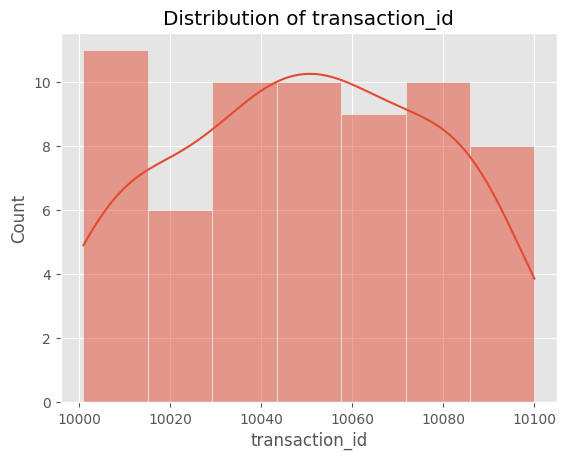

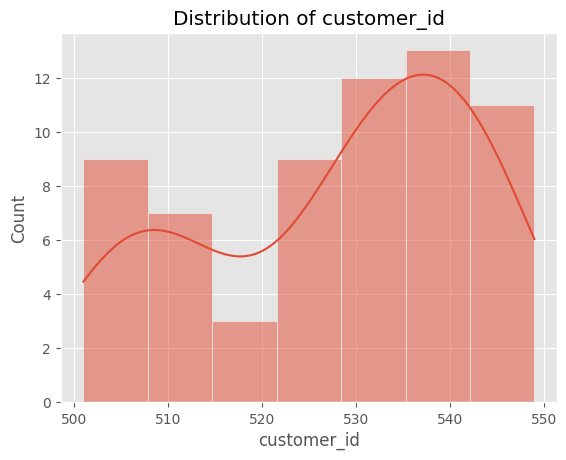

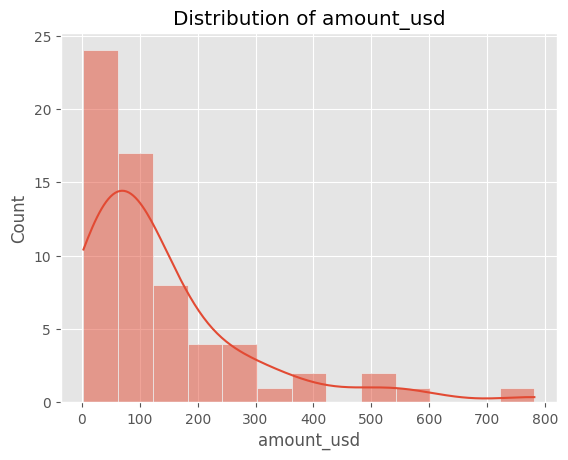

In [ ]:
# Distribution plots
for col in numeric_cols: # isme numeric type ke columns ke distribution plot banayenge
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

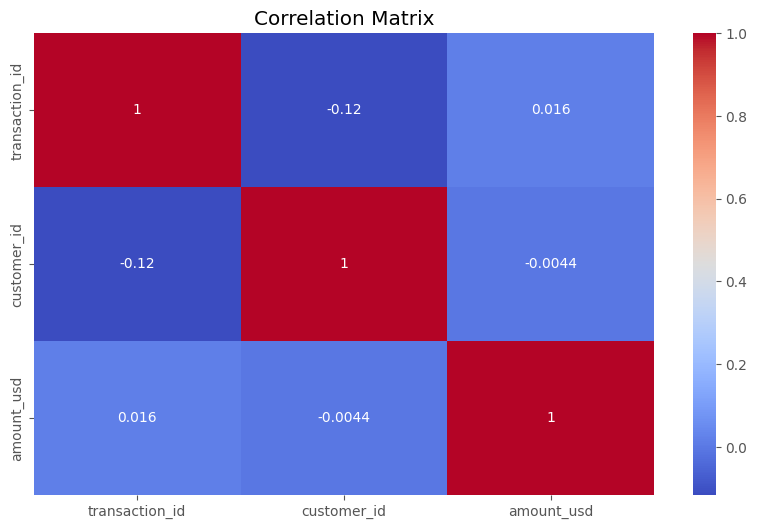

In [60]:
# Correlation matrix
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [62]:
# Remove ID-like columns before correlation
corr_cols = ["amount_usd"]  # plus other real numeric measures
df[corr_cols].corr()


,amount_usd
amount_usd,1.0


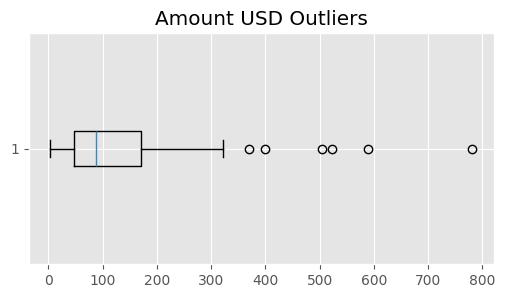

In [61]:
# Boxplot to visually confirm outliers
plt.figure(figsize=(6, 3))
plt.boxplot(df["amount_usd"], vert=False)
plt.title("Amount USD Outliers")
plt.show()


In [63]:
# Final validation
df.shape
df.isnull().sum()

transaction_id      0
customer_id         0
transaction_date    0
amount_usd          0
payment_type        0
currency            0
dtype: int64

In [64]:
# Export cleaned dataset
df.to_csv('cleaned_data.csv', index=False)